In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import quopri
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [27]:
file = r"D:\new_project\Nazario.csv"
df = pd.read_csv(file)
df.head()

,Sender,Reciever,Date,Subject,Body,URL,Label
0,"""ibsupport@standardbank.co.za"" <ibsupport@stan...",jose@monkey.org,"Fri, 18 Nov 2016 07:12:03 +0000",Foreign debit notification,Dear customer Your card has been used for an o...,1,1
1,"""Admin"" <info@admin.org>",Recipients <info@admin.org>,"Thu, 17 Nov 2016 16:09:38 -0800",Email Quota,All email users are to click on this link:http...,0,1
2,"""USAA""<online.banking.restricted@information.com>",jose@monkey.org,19-11-2016 16:42,Subscribed Alert: Important Notice On Your USA...,"To ensure delivery to your inbox, ...",1,1
3,"""Chase. Online."" <mikeb@mjboyle.com>",Recipients <mikeb@mjboyle.com>,"Mon, 21 Nov 2016 09:46:45 -0800",Account: Avoid Service Interruption.,"Avoid Service Interruption! Dear Customer, P...",0,1
4,"""USAA"" <USAA.Communicationss@us.com>",Recipients <USAA.Communicationss@us.com>,"Sun, 27 Nov 2016 07:25:15 -0500",USAA Detected Suspicious Activity,"To ensure delivery to your inbox, please add U...",1,1


In [28]:
df.columns

Index(['Sender', 'Reciever', 'Date', 'Subject', 'Body', 'URL', 'Label'], dtype='object')

In [29]:
df['Label'] = pd.to_numeric(df['Label'], errors='coerce')
df['URL'] = pd.to_numeric(df['URL'], errors='coerce')

print("Count rows:", df['Label'].isna().sum())

Count rows: 0


In [30]:
print("Null values count:", df.isnull().sum())
print("Duplicate value count:", df.duplicated().sum())
print("Missing value count:", df.isnull().values.any())
print("Information about data:", df.info())
print("Description about data:", df.describe())

Null values count: Sender      0
Reciever    0
Date        0
Subject     0
Body        0
URL         0
Label       0
dtype: int64
Duplicate value count: 0
Missing value count: False
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sender    1096 non-null   object
 1   Reciever  1096 non-null   object
 2   Date      1096 non-null   object
 3   Subject   1096 non-null   object
 4   Body      1096 non-null   object
 5   URL       1096 non-null   int64 
 6   Label     1096 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 60.1+ KB
Information about data: None
Description about data:                URL   Label
count  1096.000000  1096.0
mean      0.931569     1.0
std       0.252599     0.0
min       0.000000     1.0
25%       1.000000     1.0
50%       1.000000     1.0
75%       1.000000     1.0
max       1.000000     1.0


In [31]:
df['sender_detail'] = df['Sender'].str.split('@').str[1]
print(df['sender_detail'])

df['Subject_count'] = df['Subject'].str.len()
print(df['Subject_count'])

df['body_count'] = df['Body'].str.len()
print(df['body_count'])

0       standardbank.co.za" <ibsupport
1                           admin.org>
2                     information.com>
3                         mjboyle.com>
4                              us.com>
                     ...              
1091          advantageapartments.com>
1092                       monkey.org>
1093                em5269.xfund02.ml>
1094                    sofamekar.com>
1095                em5269.xfund02.ml>
Name: sender_detail, Length: 1096, dtype: object
0       26
1       11
2       63
3       36
4       33
        ..
1091    32
1092    37
1093    74
1094    38
1095    27
Name: Subject_count, Length: 1096, dtype: int64
0       1528
1        122
2        988
3        528
4       2435
        ... 
1091    3239
1092     155
1093    1151
1094     467
1095    1239
Name: body_count, Length: 1096, dtype: int64


In [32]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text  

df['cleaned_subject'] = df['Subject'].apply(clean_text)
#Frequency count : most used word
all_words = " ".join(df['cleaned_subject']).split()

stop_words = {'the','to', 'a', 'and', 'in', 'of', 'for', 'is', 'your', 're', 'fwd', 'you'}
filtered_words = [word for word in all_words if word not in stop_words and len(word) > 2]

top_words = Counter(filtered_words).most_common(50)
print(top_words)

urgent_list = [
    'account', 'update', 'notification', 'security', 'alert', 
    'notice', 'pending', 'warning', 'urgent', 'required', 
    'verification', 'verify', 'payment', 'billing', 'statement', 
    'incoming', 'upgrade', 'received', 'deactivation', 'locked', 
    'confirm', 'action', 'trouble', 'password', 'important', 'now'
    'suspicious', 'activity', 'detected', 'interruption', 'termination'
]

def get_urgent_count(text):
    words = text.split()
    return sum(1 for word in words if word in urgent_list)

df['urgent_word_count'] = df['cleaned_subject'].apply(get_urgent_count)
print(df[['Subject', 'urgent_word_count']].head(25))

[('account', 200), ('josemonkeyorg', 164), ('email', 112), ('update', 82), ('notification', 73), ('new', 59), ('security', 58), ('has', 53), ('have', 53), ('mailbox', 51), ('information', 48), ('important', 44), ('pending', 44), ('alert', 42), ('notice', 42), ('incoming', 41), ('message', 38), ('mail', 38), ('payment', 36), ('been', 36), ('messages', 36), ('warning', 32), ('with', 32), ('monkeyorg', 31), ('will', 30), ('some', 29), ('from', 27), ('upgrade', 26), ('required', 26), ('now', 25), ('billing', 25), ('received', 24), ('verification', 23), ('please', 23), ('delivery', 23), ('via', 23), ('action', 22), ('having', 22), ('trouble', 22), ('password', 21), ('current', 21), ('locked', 20), ('statement', 20), ('confirm', 20), ('document', 19), ('online', 19), ('deactivation', 19), ('request', 19), ('verify', 19), ('were', 19)]
                                              Subject  urgent_word_count
0                          Foreign debit notification                  1
1            

In [33]:
print(df['urgent_word_count'].max())

5


In [34]:
print(df.head(25))

                                               Sender  \
0   "ibsupport@standardbank.co.za" <ibsupport@stan...   
1                            "Admin" <info@admin.org>   
2   "USAA"<online.banking.restricted@information.com>   
3                "Chase. Online." <mikeb@mjboyle.com>   
4                "USAA" <USAA.Communicationss@us.com>   
5             "Mail Administrator" <Owenemery@qq.com>   
6                   "USAA" <codewizard@approject.com>   
7                    Victoria Brown <vbrown@sbch.org>   
8                   "USAA" <codewizard@approject.com>   
9               "System Administrator"<steve@awoc.ca>   
10       Account Support <support@paypal.cgi-bin.com>   
11    Soumeya Dalaa <soumeya.dalaa@OCMW.Antwerpen.be>   
12            Alma Vega <Alma.Vega@williamoslerhs.ca>   
13  "ibsupport@standardbank.co.za" <ibsupport@stan...   
14                  "USAA" <codewizard@approject.com>   
15                         "Nicole" <info@pxsend.com>   
16                "i.AppStore  

In [35]:
df['Sender'].count()

np.int64(1096)

In [36]:
# Check urgencyscore
print("check urgency score:", df['urgent_word_count'].describe())

#percentage of high risk email
high_risK = len(df[df['urgent_word_count'] >= 3])
total = len(df)
print(f"\n High Risk emails: {high_risK} ({ (high_risK/total)*100 : .2f}%)")


check urgency score: count    1096.000000
mean        0.946168
std         0.949801
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: urgent_word_count, dtype: float64

 High Risk emails: 58 ( 5.29%)


In [37]:
print(df[['Subject', 'Sender', 'Body']].isnull().sum())

Subject    0
Sender     0
Body       0
dtype: int64


In [38]:
duplicates = df['Subject'].duplicated().sum()
print(f"Total Duplicate Subjects: {duplicates}")

Total Duplicate Subjects: 82


In [39]:
print(df[df['urgent_word_count'] == 0]['Subject'].head(20))

1                                        Email Quota
7                          RE: ICT Technical Support
9                                       Your Mailbox
11                                 RE: ITS help desk
12                                 RE: ITS help desk
15                            PayPal Funds Available
17                                    Server Message
18        YOUR MAILBOX QUOTA IS FULL jose@monkey.org
27                              You got new message!
28         =?utf-8?Q?Email=20Termination=20Request?=
30                           Your parcel has arrived
32            Your online login has been compromised
36                                E-mail Blacklisted
38                                  RE: HELP CENTER!
40                         DHL YOUR PACKAGE ARRIVED 
43              Re; Barclay Bank Reference attached.
45             USAA Electronic Wire Transfer Message
49             MailboxWarning/Mailbox is almost full
54    MAERSK LINE PRO-FORMA DETENTION INVOICE/

In [40]:
# 1. Nayi list jo aapke discovered patterns par base hai
logistics_list = ['parcel', 'package', 'dhl', 'delivery', 'arrived', 'shipping', 'maersk', 'invoice']
it_support_list = ['support', 'helpdesk', 'quota', 'mailbox', 'admin', 'administrator', 'its', 'server', 'termination', 'blacklisted', 'its']
finance_list = ['paypal', 'bank', 'wire', 'transfer', 'funds', 'available', 'payment', 'invoice', 'debit' 'checking', 'savings']

# 2. Inka count nikalne ka logic
df['logistics_score'] = df['cleaned_subject'].apply(lambda x: sum(1 for w in x.split() if w in logistics_list))
df['it_score'] = df['cleaned_subject'].apply(lambda x: sum(1 for w in x.split() if w in it_support_list))

# 3. Total Risk Score
df['Total_Risk_Score'] = df['urgent_word_count'] + df['logistics_score'] + df['it_score']

# Ab dekhiye kitne 0 score wale ab "Caught" (pakde gaye) ho gaye hain
print(df[df['urgent_word_count'] == 0][['Subject', 'Total_Risk_Score']].head(10))

                                       Subject  Total_Risk_Score
1                                  Email Quota                 1
7                    RE: ICT Technical Support                 1
9                                 Your Mailbox                 1
11                           RE: ITS help desk                 1
12                           RE: ITS help desk                 1
15                      PayPal Funds Available                 0
17                              Server Message                 1
18  YOUR MAILBOX QUOTA IS FULL jose@monkey.org                 2
27                        You got new message!                 0
28   =?utf-8?Q?Email=20Termination=20Request?=                 0


In [41]:
# Super List (Analyst refined)
urgency_list = ['urgent', 'alert', 'notice', 'important', 'warning', 'security', 'verification', 'verify', 'required']

# In sabko combine karke ek 'Global Suspicious List' banaiye
total_suspicious_list = it_support_list + finance_list + urgency_list

# Score calculation
df['Total_Risk_Score'] = df['cleaned_subject'].apply(lambda x: sum(1 for word in x.split() if word in total_suspicious_list))

# Now see 'Your Mailbox' or 'PayPal' score
print(df[['Subject', 'Total_Risk_Score']].head(30))

                                              Subject  Total_Risk_Score
0                          Foreign debit notification                 0
1                                         Email Quota                 1
2   Subscribed Alert: Important Notice On Your USA...                 4
3                Account: Avoid Service Interruption.                 0
4                   USAA Detected Suspicious Activity                 0
5                                    Data Usage Alert                 1
6                       URGENT SECURITY CHECK FAILURE                 2
7                           RE: ICT Technical Support                 1
8               Your Account Urgent Document Is Ready                 1
9                                        Your Mailbox                 1
10                               Account Notification                 0
11                                  RE: ITS help desk                 1
12                                  RE: ITS help desk           

In [42]:
advanced_list = total_suspicious_list + ['usaa', 'paypal', 'dhl', 'message', 'login', 'compromised']

print("--- TOP 10 HIGH RISK EMAILS ---")

# To see highest score
print(df[['Subject', 'Total_Risk_Score']].sort_values(by='Total_Risk_Score', ascending=False).head(10))

print("\n--- ZERO SCORE CHECK (RE-EVALUATION) ---")

# now check
zero_score_data = df[df['Total_Risk_Score'] == 0]
print(f"Ab total {len(zero_score_data)} emails ka score 0 reh gaya hai.")
print(zero_score_data[['Subject']].head(10))

--- TOP 10 HIGH RISK EMAILS ---
                                               Subject  Total_Risk_Score
42   Warning MailBox Termination De-activation Alert!                  4
2    Subscribed Alert: Important Notice On Your USA...                 4
130         Incoming Funds Transfer Confirmation Alert                 3
508       Urgent Server Warning  For   jose@monkey.org                 3
239                          Important Security Notice                 3
132     Urgent - New Incoming Payment Transfer On Hold                 3
342  RE: Urgent Computer Security Update - Your Act...                 3
167  Your Mailbox Quota Almost Full (VERIFY TO AVOI...                 3
312  FINAL WARNING!! {jose@monkey.org}Your mailbox ...                 3
251  Security Alert: Your Access to Bank of America...                 3

--- ZERO SCORE CHECK (RE-EVALUATION) ---
Ab total 703 emails ka score 0 reh gaya hai.
                                              Subject
0                       

In [43]:
# Analyst Audit Code: Check why these are 0
print("--- Analyst Debugging ---")
# 'account' check karte hain list mein hai ya nahi
print(f"Is 'account' in our list? {'account' in total_suspicious_list}") 

# Decoding check (Row 28 fix)

def decode_subject(text):
    try:

        return quopri.decodestring(text).decode('utf-8', 'ignore')
    except:
        return text

--- Analyst Debugging ---
Is 'account' in our list? False


In [44]:
# 1. Refined Master List 
master_list = [
    'account', 'update', 'verify', 'verification', 'security', 'alert', 
    'notification', 'notice', 'important', 'urgent', 'warning', 'confirm',
    'payment', 'funds', 'paypal', 'bank', 'transfer', 'invoice', 'debit',
    'mailbox', 'quota', 'server', 'its', 'helpdesk', 'parcel', 'dhl', 
    'termination', 'blacklisted', 'locked', 'suspicious'
]

df['Total_Risk_Score'] = df['cleaned_subject'].apply(lambda x: sum(1 for word in x.split() if word in master_list))

# Now check result
print(df[['Subject', 'Total_Risk_Score']].head(25))

                                              Subject  Total_Risk_Score
0                          Foreign debit notification                 2
1                                         Email Quota                 1
2   Subscribed Alert: Important Notice On Your USA...                 4
3                Account: Avoid Service Interruption.                 1
4                   USAA Detected Suspicious Activity                 1
5                                    Data Usage Alert                 1
6                       URGENT SECURITY CHECK FAILURE                 2
7                           RE: ICT Technical Support                 0
8               Your Account Urgent Document Is Ready                 2
9                                        Your Mailbox                 1
10                               Account Notification                 2
11                                  RE: ITS help desk                 1
12                                  RE: ITS help desk           

In [45]:
# 1. clean body and return score
df['cleaned_body'] = df['Body'].apply(clean_text)
df['Body_Risk_Score'] = df['cleaned_body'].apply(lambda x: sum(1 for word in x.split() if word in master_list))

# 2. Final Total Score (Subject + Body)
df['Final_Threat_Score'] = df['Total_Risk_Score'] + df['Body_Risk_Score']

# 3. Top Most Dangerous Emails (Overall)
print("--- TOP 5 MOST DANGEROUS EMAILS (SUBJECT + BODY) ---")
print(df[['Subject', 'Final_Threat_Score']].sort_values(by='Final_Threat_Score', ascending=False).head(5))

--- TOP 5 MOST DANGEROUS EMAILS (SUBJECT + BODY) ---
                                               Subject  Final_Threat_Score
267                                      Re...........                 107
403               NedBank Account Statement - 18-09-22                  50
947  =?UTF-8?Q?Wir_brauchen_Ihre_Hilfe,_um_ein_Prob...                  50
325  Special Security Notice Posted : Tue, May 1, 2018                  50
432                 NedBank Account Statement 18-10-12                  49


Correlation: 0.17


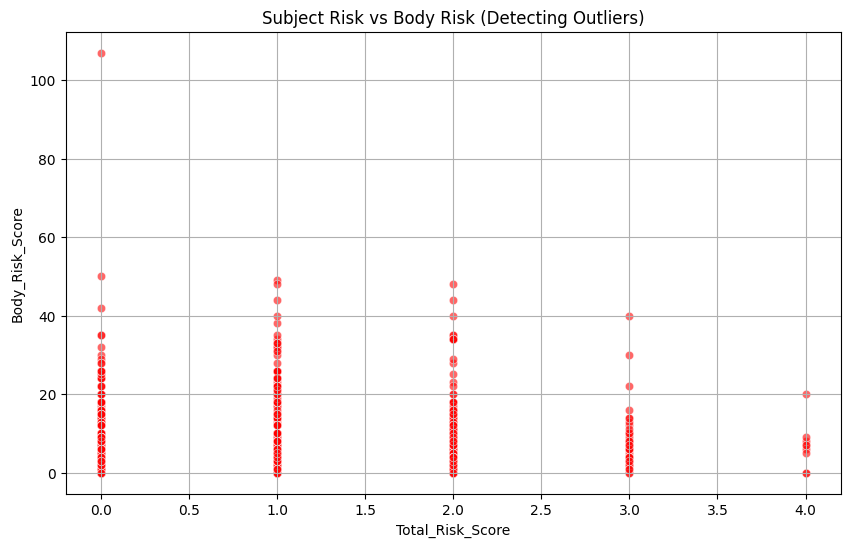

In [46]:
# 1. Subject vs Body Correlation 
correlation = df['Total_Risk_Score'].corr(df['Body_Risk_Score'])
print(f"Correlation: {correlation:.2f}")

# 2. Scatter Plot (Visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total_Risk_Score', y='Body_Risk_Score', color='red', alpha=0.6)
plt.title('Subject Risk vs Body Risk (Detecting Outliers)')
plt.grid(True)
plt.show()

In [47]:
# Only OUtilier 
outlier_row = df.loc[267]

print("--- OUTLIER DEEP DIVE (Index 267) ---")
print(f"Subject: {outlier_row['Subject']}")
print(f"Total Score: {outlier_row['Final_Threat_Score']}")
print("-" * 30)
print("BODY SNIPPET (First 500 chars):")
print(outlier_row['Body'][:500]) # Poori body badi ho sakti hai, isliye pehle 500 characters

--- OUTLIER DEEP DIVE (Index 267) ---
Subject: Re...........
Total Score: 107
------------------------------
BODY SNIPPET (First 500 chars):
@import url(http://image.email.office.com/lib/fe9815707264017b71/m/1/fontface2.css); #outlook a {padding:0;} .ReadMsgBody {width:100%;} .ExternalClass{width:100%;} .ExternalClass, .ExternalClass p, .ExternalClass span, .ExternalClass font, .ExternalClass td, .ExternalClass div {line-height: 100%;} body, table, td, a {-webkit-text-size-adjust:100%; -ms-text-size-adjust:100%;} table, td {mso-table-lspace:0pt; mso-table-rspace:0pt; border-collapse: collapse;} img {-ms-interpolation-mode:bicubic !im


--- TOP 5 ATTACKER DOMAINS ---
Sender_Domain
monkey.org            38
wetransfer.com        12
standardbank.co.za    10
absa.co.za            10
approject.com          9
Name: count, dtype: int64

Success! Graphs saved. Project 95% complete.


C:\Users\ruchi\AppData\Local\Temp\ipykernel_20184\2100677604.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Risk_Level', palette='magma')


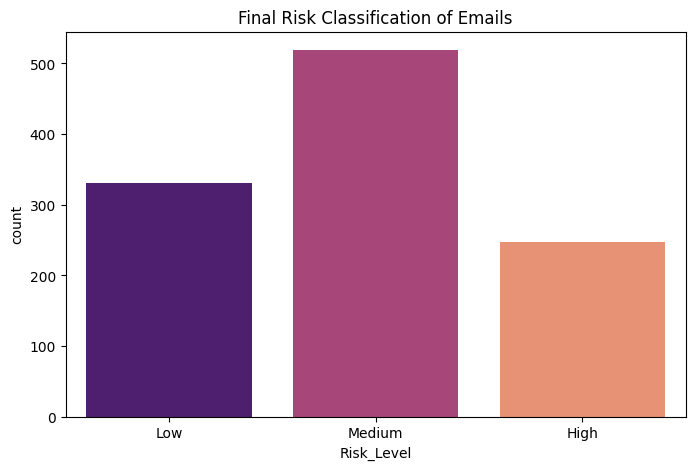

In [48]:
# 1. Function for removing HTML tags
def super_clean_body(text):
    if pd.isna(text): return ""

    clean = re.sub(r'<.*?>', ' ', text)
    
    clean = re.sub(r'{.*?}', ' ', clean)

    clean = re.sub(r'[^a-z\s]', ' ', clean.lower())
    return " ".join(clean.split())

# 2. Domain Extraction
def get_domain(sender):
    try:
        return sender.split('@')[-1].split('>')[0].strip()
    except:
        return "unknown"

df['Sender_Domain'] = df['Sender'].apply(get_domain)
df['cleaned_body_final'] = df['Body'].apply(super_clean_body)

# 3. Recalculate Score with Cleaned Body
df['Body_Score_Fixed'] = df['cleaned_body_final'].apply(lambda x: sum(1 for word in x.split() if word in master_list))

#GENERATING INSIGHTS

print("--- TOP 5 ATTACKER DOMAINS ---")
print(df['Sender_Domain'].value_counts().head(5))

# Visualization: Risk Level Distribution
df['Risk_Level'] = pd.cut(df['Body_Score_Fixed'], bins=[-1, 2, 10, 1000], labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Risk_Level', palette='magma')
plt.title('Final Risk Classification of Emails')
plt.savefig('final_risk_distribution.png')

print("\nSuccess! Graphs saved. Project 95% complete.")

--- TOP 10 PHISHING DOMAINS ---
Sender_Domain
monkey.org            38
wetransfer.com        12
standardbank.co.za    10
absa.co.za            10
approject.com          9
support.com            9
t-online.de            8
gmail.com              8
cox.net                8
MailSender.com         7
Name: count, dtype: int64

--- FINAL PROJECT SUMMARY ---
Total Emails Analyzed: 1096
Dangerous Emails (High Risk): 247 (22.5%)
Suspicious Emails (Medium Risk): 519 (47.4%)


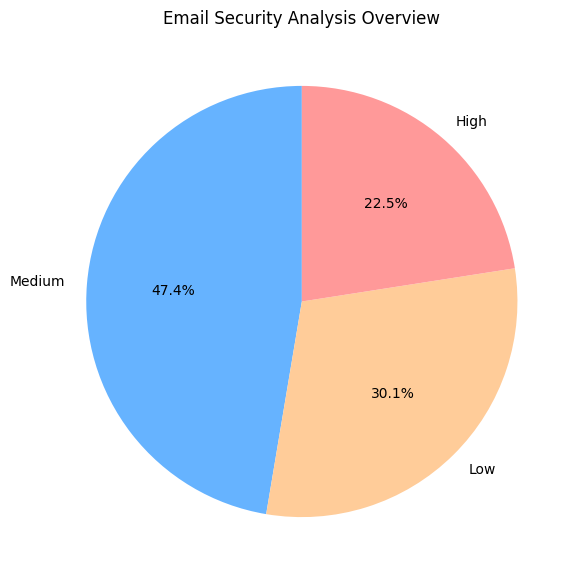

In [49]:
# 1. Top 10 Attackers
print("--- TOP 10 PHISHING DOMAINS ---")
top_domains = df['Sender_Domain'].value_counts().head(10)
print(top_domains)

# 2. Final Project Statistics
total_emails = len(df)
high_risk = len(df[df['Risk_Level'] == 'High'])
medium_risk = len(df[df['Risk_Level'] == 'Medium'])

print(f"\n--- FINAL PROJECT SUMMARY ---")
print(f"Total Emails Analyzed: {total_emails}")
print(f"Dangerous Emails (High Risk): {high_risk} ({ (high_risk/total_emails)*100 :.1f}%)")
print(f"Suspicious Emails (Medium Risk): {medium_risk} ({ (medium_risk/total_emails)*100 :.1f}%)")

# 3. Pie Chart for Presentation
plt.figure(figsize=(7,7))
df['Risk_Level'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ffcc99','#ff9999'], startangle=90)
plt.title('Email Security Analysis Overview')
plt.ylabel('') # Hiding the ylabel for a cleaner look
plt.savefig('final_project_summary.png')
plt.show()

In [51]:
print(df)

# convert df to excel\cssv
df.to_csv('Phishing Emails thread inteligence.csv', index = False)
print("file saves successfully!")

                                                 Sender  \
0     "ibsupport@standardbank.co.za" <ibsupport@stan...   
1                              "Admin" <info@admin.org>   
2     "USAA"<online.banking.restricted@information.com>   
3                  "Chase. Online." <mikeb@mjboyle.com>   
4                  "USAA" <USAA.Communicationss@us.com>   
...                                                 ...   
1091  info advantageapartments.com <info@advantageap...   
1092                   monkey.org <HELPDESK@monkey.org>   
1093  Help Center\n\t<info.help-center.co.za_info.he...   
1094                     MetaMask  <info@sofamekar.com>   
1095  Fastway\n\t<info.fastway.co.za_info.fastway.co...   

                                      Reciever  \
0                              jose@monkey.org   
1                  Recipients <info@admin.org>   
2                              jose@monkey.org   
3               Recipients <mikeb@mjboyle.com>   
4     Recipients <USAA.Communicationss@us